In [1]:
import pandas as pd
import numpy as np

# 1. 1차 정제 데이터 로드
df = pd.read_csv('../data/interim/non_english_tv_clean.csv')
df['week'] = pd.to_datetime(df['week'])

# 2. 작품별 수명 및 시청시간 요약 집계
show_summary = df.groupby('show_title').agg(
    max_weeks_in_top10=('cumulative_weeks_in_top_10', 'max'),
    total_hours_viewed=('weekly_hours_viewed', 'sum'),
    peak_hours=('weekly_hours_viewed', 'max'),
    first_week=('week', 'min'),
    last_week=('week', 'max')
).reset_index()

# 3. 흥행 지속 기간별 그룹 라벨링
show_summary['lifecycle_group'] = np.where(
    show_summary['max_weeks_in_top10'] >= 8, 'Long-run (>=8w)',
    np.where(show_summary['max_weeks_in_top10'] <= 4, 'Short-run (<=4w)', 'Mid-run (5-7w)')
)

# 4. processed 폴더에 저장
summary_path = '../data/processed/02_show_retention_summary.csv'
show_summary.to_csv(summary_path, index=False)

print("=== 작품별 수명 주기 분류 결과 ===")
print(show_summary['lifecycle_group'].value_counts())
print(f"\n저장 완료 -> {summary_path}")
show_summary.sort_values(by='max_weeks_in_top10', ascending=False).head(5)

=== 작품별 수명 주기 분류 결과 ===
lifecycle_group
Short-run (<=4w)    517
Mid-run (5-7w)       90
Long-run (>=8w)      59
Name: count, dtype: int64

저장 완료 -> ../data/processed/02_show_retention_summary.csv


,show_title,max_weeks_in_top10,total_hours_viewed,peak_hours,first_week,last_week,lifecycle_group
469,Squid Game,32,5048300000,571760000,2021-09-19,2025-08-24,Long-run (>=8w)
654,"Yo soy Betty, la fea",30,297560000,12570000,2021-08-29,2022-07-10,Long-run (>=8w)
81,Café con aroma de mujer,28,813480000,98850000,2022-01-02,2022-11-27,Long-run (>=8w)
22,Alchemy of Souls,21,419030000,28590000,2022-07-03,2023-04-23,Long-run (>=8w)
166,Extraordinary Attorney Woo,21,662090000,77430000,2022-07-10,2022-12-04,Long-run (>=8w)


C:\Users\user\AppData\Local\Temp\ipykernel_5656\252932058.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


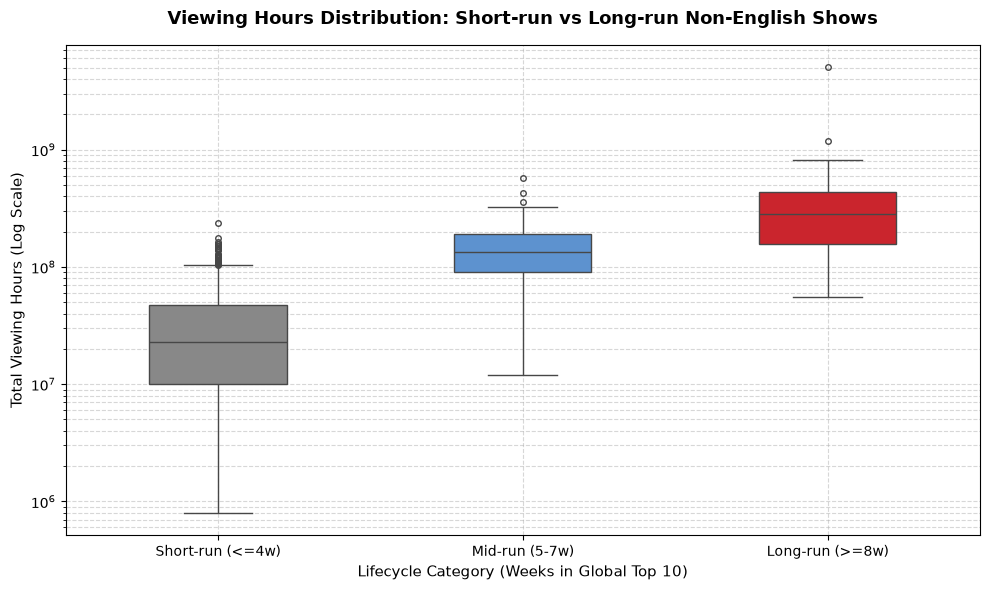

차트 3 저장 완료 -> ../images/03_longrun_vs_shortrun_box.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 박스플롯 (로그 스케일 적용하여 이상치와 분포를 명확히 표시)
order = ['Short-run (<=4w)', 'Mid-run (5-7w)', 'Long-run (>=8w)']
palette = {'Short-run (<=4w)': '#888888', 'Mid-run (5-7w)': '#4A90E2', 'Long-run (>=8w)': '#E50914'}

ax = sns.boxplot(
    data=show_summary,
    x='lifecycle_group',
    y='total_hours_viewed',
    order=order,
    palette=palette,
    width=0.45,
    fliersize=4
)
ax.set_yscale('log')

plt.title('Viewing Hours Distribution: Short-run vs Long-run Non-English Shows', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Lifecycle Category (Weeks in Global Top 10)', fontsize=11)
plt.ylabel('Total Viewing Hours (Log Scale)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, which='both')
plt.tight_layout()

# 이미지 저장
chart3_path = '../images/03_longrun_vs_shortrun_box.png'
plt.savefig(chart3_path, dpi=300)
plt.show()
print(f"차트 3 저장 완료 -> {chart3_path}")

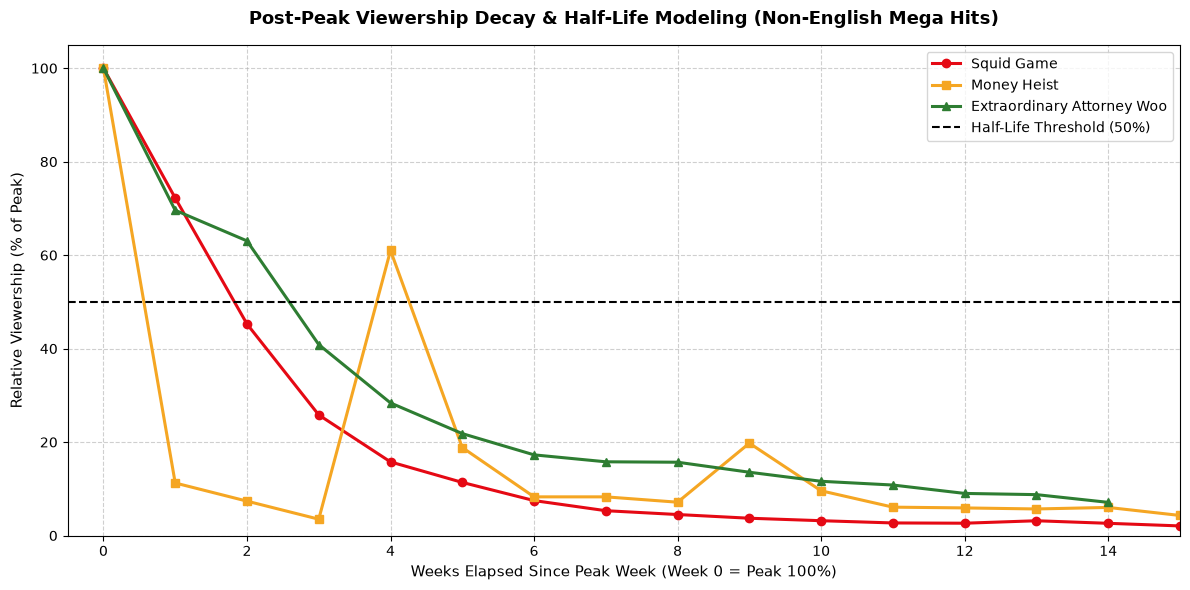

차트 4 저장 완료 -> ../images/04_normalized_decay_halflife.png


In [3]:
# 1. 분석 대상 대표작 3편 선정
target_shows = ['Squid Game', 'Money Heist', 'Extraordinary Attorney Woo']
df_decay = df[df['show_title'].isin(target_shows)].copy()

# 2. 작품별 Peak 시청시간 기준 정규화 (%)
decay_records = []
for show in target_shows:
    sub = df_decay[df_decay['show_title'] == show].sort_values('week').reset_index(drop=True)
    peak_val = sub['weekly_hours_viewed'].max()
    sub['normalized_pct'] = (sub['weekly_hours_viewed'] / peak_val) * 100
    
    # Peak 도달 주차를 0주차(Peak Week)로 설정
    peak_idx = sub['normalized_pct'].idxmax()
    sub['relative_week_from_peak'] = range(-peak_idx, len(sub) - peak_idx)
    
    # Peak 이후 데이터만 슬라이싱 (감쇄 구간)
    post_peak = sub[sub['relative_week_from_peak'] >= 0].copy()
    post_peak['weeks_since_peak'] = post_peak['relative_week_from_peak']
    decay_records.append(post_peak)

df_decay_post = pd.concat(decay_records, ignore_index=True)

# 3. processed 폴더에 저장
decay_path = '../data/processed/03_decay_normalized.csv'
df_decay_post.to_csv(decay_path, index=False)

# 4. 차트 4 시각화
plt.figure(figsize=(12, 6))

colors = {'Squid Game': '#E50914', 'Money Heist': '#F5A623', 'Extraordinary Attorney Woo': '#2E7D32'}
markers = {'Squid Game': 'o', 'Money Heist': 's', 'Extraordinary Attorney Woo': '^'}

for show in target_shows:
    sub = df_decay_post[df_decay_post['show_title'] == show]
    plt.plot(sub['weeks_since_peak'], sub['normalized_pct'], 
             label=show, color=colors[show], marker=markers[show], linewidth=2.2, markersize=6)

# 50% 반감기 기준선 (Half-Life Threshold)
plt.axhline(50, color='black', linestyle='--', linewidth=1.5, label='Half-Life Threshold (50%)')

plt.title('Post-Peak Viewership Decay & Half-Life Modeling (Non-English Mega Hits)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Weeks Elapsed Since Peak Week (Week 0 = Peak 100%)', fontsize=11)
plt.ylabel('Relative Viewership (% of Peak)', fontsize=11)
plt.xlim(-0.5, 15)
plt.ylim(0, 105)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 이미지 저장
chart4_path = '../images/04_normalized_decay_halflife.png'
plt.savefig(chart4_path, dpi=300)
plt.show()
print(f"차트 4 저장 완료 -> {chart4_path}")